In [1]:
import numpy as np
import imputation_utils
imputation_utils.CACHE_BASE_PATH = "../data/imputation_cache/5yr/"
from imputation_utils import char_groupings, char_maps
data = np.load('../data/raw_rank_trunk_chars_5yr.npz')
percentile_rank_chars = data['rank_chars']
regular_chars = data['raw_chars']
chars = data['chars']
dates = data['dates']
return_panel = data['returns']
permnos = data['permnos']
rts = data['rfs']

from plots_and_tables import section_4

# Section 4


## Figure 7: Eigenvalues of Σ

This figure shows the magnitude of eigenvalues of the characteristic covariance matrix Σ̂ relative to the
sum of all eigenvalues averaged over time.

saving to save_loc


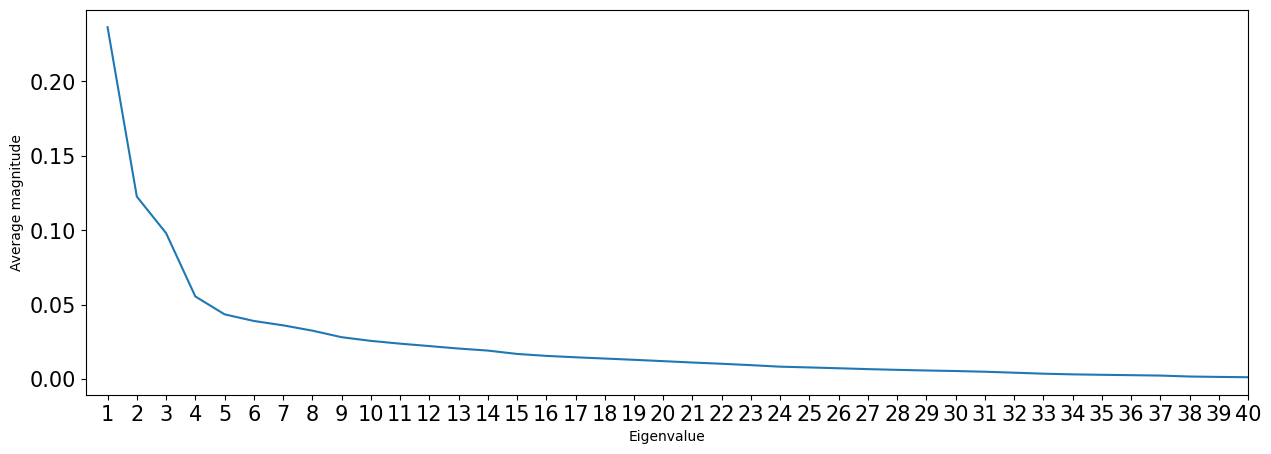

CPU times: user 5.28 s, sys: 135 ms, total: 5.42 s
Wall time: 5.51 s


In [2]:
%%time 

plot = section_4.XS_Factor_EV()
plot.setup(return_panel=return_panel, percentile_rank_chars=percentile_rank_chars)
plot.run()

## Figure 8: Number of Factors and Regularization 
The top panel shows the out-of-sample 𝑅2 of the local XS model for different number of latent factors and regularization for three masking schemes missing-completely-at-random, block-missing and logit-missing. The bottom panel shows the incremental change in out-of-sample 𝑅2 for adding factors. The 𝑅2 is the explained variation relative to a cross-sectional median imputation.

**CPU times: user 1h 34min 39s, sys: 56min 41s, total: 2h 31min 21s**
Wall time: 3h 49min 28s

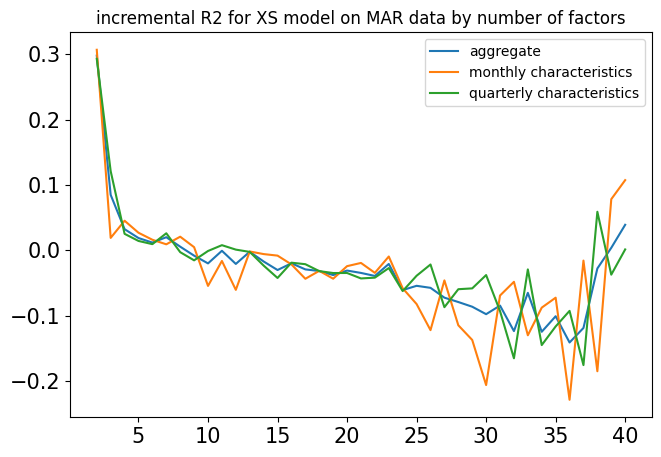

saving to save_loc


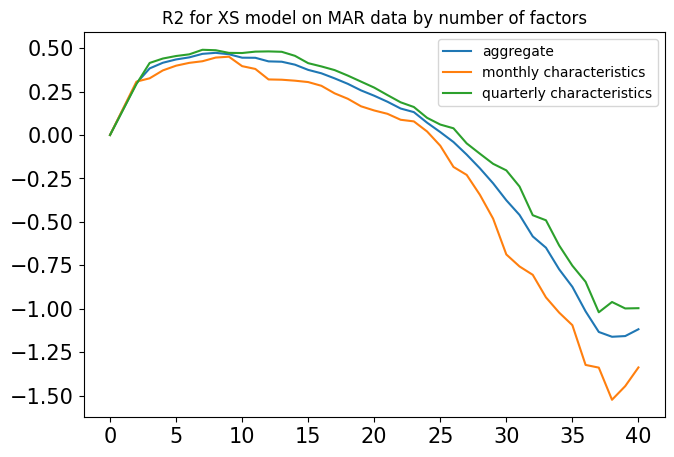

KeyboardInterrupt: 

In [3]:
%%time 

for data_source in ['MAR', 'prob_block', 'logit']:
    for reg in [0, 1e-4, 1e-3, 1e-2]:
        plot = section_4.Optimal_Num_Factors()
        plot.setup(percentile_rank_chars=percentile_rank_chars, return_panel=return_panel, chars=chars, 
                   tag=data_source, factor_nums=range(2, 41, 1), reg=reg, eval_weight=True,
                  recalc_data=True)
        plot.run()

## Figure 9: Optimal Regularization 

This figure shows the out-of-sample 𝑅2 for the local XS model with 20 factors for different regularization parameters 𝛾. The 𝑅2 is the explained variation relative to a cross-sectional median imputation. The plots report the scaling constant ̃𝛾 for 𝛾 = ̃𝛾/𝐿.

CPU times: user 6min 32s, sys: 2min 57s, total: 9min 29s
Wall time: 12min 16s

In [ ]:
%%time 

for data_source in ['MAR', 'prob_block', 'logit']:
    plot = section_4.Optimal_Reg()
    plot.setup(percentile_rank_chars=percentile_rank_chars, return_panel=return_panel, chars=chars, 
               tag=data_source, num_factors=20, regs=[0, 0.0001, 0.0005, 0.001, 0.005, 0.01,
                                                      0.05, 0.1, 0.5, 1]
               ,recalc_data=True)
    plot.run()

ValueError: operands could not be broadcast together with shapes (528,18613) (60,22351) 